# UN General Debate speeches, conflict and military spending

**Fundamentals of Data Science, Assignment 1 (University of Amsterdam)**

This notebook builds one country-year dataset from three sources: UN General Debate speeches, the UCDP/PRIO Armed Conflict Dataset (v26.1) and SIPRI military expenditure. It then explores whether rhetoric and military spending in one year differ for countries that are in conflict in the following year. The scope is 1990 to 2025, and the unit is one speech.

**Contents**

1. Setup
2. Dataset I: UN General Debate speeches
3. Dataset II: UCDP/PRIO armed conflicts
4. Dataset III: SIPRI military spending
5. Merging the three datasets
6. Text pre-processing
7. Research question
8. Rhetoric scores
9. Comparing the two groups
10. Robustness check and trends
11. Summary of findings
12. Numbers used in the report

**Reproducibility.** Run all cells from top to bottom. The hour-long zero-shot scoring is switched off by default (`RUN_SCORING = False`); the saved scores are loaded instead. Figures are saved as PDF in `figures/`.

## 1. Setup

Create a `.env` file in the project folder with four paths: `data_path` (folder with the speech `.txt` files, from Canvas), `speech_path` (`Speakers_by_session.xlsx`), `conflicts_path` (UCDP CSV) and `sipri_path` (SIPRI Excel file). The UCDP and SIPRI files can be downloaded <a href='https://drive.google.com/drive/folders/1Ach27hl0Fv4v5MpKTQG63gh2urtSwI1h?usp=sharing'>here</a>. The cell below imports all libraries, loads the paths and stops if one is missing.

In [1]:
import os
import re

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
from dotenv import load_dotenv
from matplotlib.ticker import PercentFormatter
from nltk.corpus import stopwords
from scipy import stats

load_dotenv(override=True)

DATA_PATH = os.getenv("data_path")
SPEECH_PATH = os.getenv("speech_path") or os.getenv("speach_path")
CONFLICTS_PATH = os.getenv("conflicts_path")
SIPRI_PATH = os.getenv("sipri_path")

required_paths = {
    "data_path": DATA_PATH,
    "speech_path": SPEECH_PATH,
    "conflicts_path": CONFLICTS_PATH,
    "sipri_path": SIPRI_PATH,
}
missing_paths = [name for name, value in required_paths.items() if not value]
if missing_paths:
    raise ValueError(
        f"Missing environment variables: {', '.join(missing_paths)}"
    )

# All figures are saved here as PDF so the report can include them
FIGURES_PATH = "figures"
os.makedirs(FIGURES_PATH, exist_ok=True)

# The zero-shot scoring takes over an hour. Keep this False to load the saved scores instead.
RUN_SCORING = False
SCORES_PATH = "merged_data.csv"

## 2. Dataset I: UN General Debate speeches

### 2.1 Load the metadata

We load the speech metadata (one row per speech: year, session, ISO code, country, speaker and post) and drop an empty column.

In [2]:
excel = pd.read_excel(SPEECH_PATH)
# lets drop unnecessary column
speach_df = excel.drop(columns=["Unnamed: 6"])

### 2.2 Attach the speech texts

Each speech is a `.txt` file named `ISO_session_year.txt`. We match every file to its metadata row on ISO code, session and year. Session and year are compared as integers, because the file names are zero-padded ("05" vs 5).

In [3]:
# Make the Excel values use the same types as the values in the filenames.
speach_df["ISO Code"] = speach_df["ISO Code"].astype(str).str.strip()
speach_df["Session"] = pd.to_numeric(speach_df["Session"])
speach_df["Year"] = pd.to_numeric(speach_df["Year"])

if "Speech" not in speach_df.columns:
    speach_df["Speech"] = pd.NA

number_of_sessions = 0
files_processed = 0
files_matched = 0
files_unmatched = 0
files_skipped = 0
skipped_files = []
unmatched_files = []

for folder_name in os.listdir(DATA_PATH):
    folder_path = os.path.join(DATA_PATH, folder_name)
    if not os.path.isdir(folder_path):
        continue

    for session_name in os.listdir(folder_path):
        session_path = os.path.join(folder_path, session_name)
        if not os.path.isdir(session_path):
            continue

        number_of_sessions += 1

        for txt_file in os.listdir(session_path):
            if not txt_file.endswith(".txt"):
                continue

            parts = txt_file[:-4].split("_")
            if len(parts) != 3:
                files_skipped += 1
                skipped_files.append(txt_file)
                continue

            iso_code, session_num, year = parts
            try:
                session_num = int(session_num)
                year = int(year)
            except ValueError:
                files_skipped += 1
                skipped_files.append(txt_file)
                continue

            try:
                with open(os.path.join(session_path, txt_file), "r", encoding="utf-8") as file:
                    speech_text = file.read()
            except (OSError, UnicodeDecodeError):
                files_skipped += 1
                skipped_files.append(txt_file)
                continue

            files_processed += 1
            mask = (
                (speach_df["ISO Code"] == iso_code.strip())
                & (speach_df["Session"] == session_num)
                & (speach_df["Year"] == year)
            )

            if not mask.any():
                files_unmatched += 1
                unmatched_files.append(txt_file)
                continue

            # Update every row when the metadata contains duplicate keys.
            speach_df.loc[mask, "Speech"] = speech_text
            files_matched += 1

missing_speeches = speach_df["Speech"].isna().sum()
print(f"Sessions found: {number_of_sessions}")
print(f"Speech files processed: {files_processed}")
print(f"Speech files matched: {files_matched}")
print(f"Speech files without a metadata match: {files_unmatched}")
print(f"Files skipped: {files_skipped} {skipped_files}")
print(f"Metadata rows without speech: {missing_speeches}")

Sessions found: 80
Speech files processed: 11141
Speech files matched: 11063
Speech files without a metadata match: 78
Files skipped: 1 ['.DS_Store-to-UTF-8.txt']
Metadata rows without speech: 54


### 2.3 Drop metadata rows without a speech

Only 54 metadata rows have no speech file, so we drop them. Missing values in `Post` become "Unknown". Expected: 11,080 speeches.

In [4]:
speach_df = speach_df.dropna(subset=["Speech"])
speach_df["Post"] = speach_df["Post"].fillna("Unknown")
print(f"Speeches: {len(speach_df)}")

Speeches: 11080


### 2.4 Clean country names

The three datasets spell the same country differently (extra spaces, typos, formal names and old names). We strip whitespace and fix one corrupted cell where a broken Excel formula ended up in `Country`. Then we apply a hand-built dictionary of true one-to-one renames to SIPRI-style names.

In [5]:
speach_df["Country"] = speach_df["Country"].str.strip()

# Fix one corrupted cell (broken Excel formula leaked into 'Country')
speach_df.loc[speach_df["Country"] == "29+C70+A7+D71:E74", "Country"] = "Ethiopia"

In [6]:
# True 1-to-1 renames: same country/entity, just an old name -> current SIPRI-style name
rename_dict = {
    "Burma": "Myanmar",
    "Union of Burma": "Myanmar",
    "Union of Myanmar": "Myanmar",
    "Myanmar / Burma": "Myanmar",
    "Ceylon": "Sri Lanka",
    "Ceylon (Sri Lanka)": "Sri Lanka",
    "Zaire": "Congo, DR",
    "Congo, Leopoldville": "Congo, DR",
    "Congo, the Democratic Republic of the/Zaire": "Congo, DR",
    "Democratic Republic of Congo": "Congo, DR",
    "Democratic Republic Of Congo": "Congo, DR",
    "Democratic Republic of the Congo": "Congo, DR",
    "DRC": "Congo, DR",
    "Congo, Brazzaville": "Congo, Republic",
    "Congo (Brazzaville": "Congo, Republic",
    "Congo, the Peoples Republic of the": "Congo, Republic",
    "Dahomey": "Benin",
    "Benin (Dahomey)": "Benin",
    "Upper Volta": "Burkina Faso",
    "Upper Volta/Burkina Faso": "Burkina Faso",
    "Siam": "Thailand",
    "Swaziland": "Eswatini",
    "Kingdom of Eswatini": "Eswatini",
    "Macedonia": "North Macedonia",
    "Macedonia, the former Yugoslav Republic of": "North Macedonia",
    "Republic of North Macedonia": "North Macedonia",
    "Kampuchea": "Cambodia",
    "Democratic Kampuchea": "Cambodia",
    "Khmer Republic": "Cambodia",
    "Cambodia /Kampuchea": "Cambodia",
    "Western Samoa": "Samoa",
    "Independent State of Samoa": "Samoa",
    "Samoa": "Samoa",
    "Timor-Leste": "Timor Leste",
    "Democratic Republic of Timor-Leste": "Timor Leste",
    "Czech Republic": "Czechia",
    "Turkey": "Türkiye",
    "Republic of Turkey": "Türkiye",
}

The cell below applies the dictionary and prints how many distinct country names are left (expected: 514).

In [7]:
speach_df["Country"] = speach_df["Country"].replace(rename_dict)
n_names_after_rename = speach_df["Country"].nunique()
print(f"Distinct country names after renaming: {n_names_after_rename}")

Distinct country names after renaming: 514


### 2.5 Flag historical entities

The USSR, Czechoslovakia, Yugoslavia, divided Germany and divided Yemen no longer exist as single countries. Mapping them to one modern successor would be wrong, so we flag them in `historical_entity_unmatched` instead of renaming them. They stay usable for text analysis but are dropped when we restrict to the study scope.

In [8]:
impossible_bucket = [
    # USSR variants
    "USSR", "USSR ", "Union of Socialist Soviet Republics",
    "Union of Sovier Socialist Republics", "Union of Soviet Socialist Republics",
    "Russian Federation (USSR)",

    # Czechoslovakia
    "Czechoslovakia", "Czechoslovak Socialist Republic",

    # Yugoslavia
    "Yugoslavia", "Serbia and Montenegro",

    # Germany (pre-unification, both sides)
    "German Democratic Republic", "Germany Democratic Republic",
    "Democratic Republic of Germany", "GDR", "DDR", "FDR", "FDR (Germany)",
    "Federal Republic Germany", "Federal Republic of Germany",
    "Republica Federal Alemana",

    # Yemen (pre-1990 unification, both sides)
    "Yemen Arab Republic",

    # Byelorussian/Ukrainian SSR (distinct UN seats pre-1991, now part of modern Belarus/Ukraine
    # via full independence, not a simple rename - USSR breakup case)
    "BSSR", "BelSSR", "Byelorussian Soviet Socialist Republic",
    "Byelorussian Soviet Socialist Repulic",
    "Belarus, Byelorussian Soviet Socialist Republic",
    "UkrSSR", "Ukraine SSR", "Ukrainian Soviet Socialist Republic",
    "Ukranian SSR", "Ukranian Soviet Socialist Republic",
]
# Flag these rows explicitly instead of dropping them
speach_df["historical_entity_unmatched"] = speach_df["Country"].isin(impossible_bucket)

"Federal Republic of Germany" is ambiguous: before 1990 it means West Germany, from 1990 on it is the official name of unified Germany. From 1990 on we therefore rename it to Germany and remove the flag.

In [9]:
mask_germany_post1990 = (
    (speach_df["Country"] == "Federal Republic of Germany")
    & (speach_df["Year"] >= 1990)
)
speach_df.loc[mask_germany_post1990, "Country"] = "Germany"
speach_df.loc[mask_germany_post1990, "historical_entity_unmatched"] = False

n_flagged = speach_df["historical_entity_unmatched"].sum()
print(f"Rows flagged as historical/unmatched: {n_flagged} of {len(speach_df)} ({n_flagged / len(speach_df):.1%})")

Rows flagged as historical/unmatched: 248 of 11080 (2.2%)


**Result:** 248 of 11,080 speeches (2.2%) are flagged as historical entities. Almost all are from before 1990; the few inside our window are the USSR, Czechoslovakia and Yugoslavia (1990 to 1993) and Yugoslavia / Serbia and Montenegro (2001 to 2005).

## 3. Dataset II: UCDP/PRIO armed conflicts

### 3.1 Load and split locations

In UCDP, one row is one conflict in one year. The `location` field can name several countries separated by ", ", so we split it into one row per country.

In [10]:
conflicts_df = pd.read_csv(CONFLICTS_PATH)

# Split multi-country location entries into separate rows.
conflicts_df = conflicts_df.assign(
    Country=conflicts_df["location"].str.split(", ")
).explode("Country")

conflicts_df["Country"] = conflicts_df["Country"].str.strip()

### 3.2 Rename and flag

We apply the same renames and historical flags as for the speeches, plus a few UCDP-specific names. In UCDP, bare "Congo" is the Republic of Congo and "DR Congo (Zaire)" is the DRC.

In [11]:
# UCDP-specific renames: same entities as before, but UCDP phrases them differently.
ucdp_rename_dict = {
    "Cambodia (Kampuchea)": "Cambodia",
    "Myanmar (Burma)": "Myanmar",
    "Madagascar (Malagasy)": "Madagascar",
    "DR Congo (Zaire)": "Congo, DR",
    "Congo": "Congo, Republic",
}

rename_dict.update(ucdp_rename_dict)

ucdp_impossible_bucket = [
    "Russia (Soviet Union)",
    "South Yemen",
    "Yemen (North Yemen)",
    "Serbia (Yugoslavia)",
    "South Vietnam",
    "Vietnam (North Vietnam)",
    "Zimbabwe (Rhodesia)",
]

impossible_bucket.extend(ucdp_impossible_bucket)

conflicts_df["Country"] = conflicts_df["Country"].replace(rename_dict)
conflicts_df["historical_entity_unmatched"] = conflicts_df["Country"].isin(impossible_bucket)

### 3.3 Year-dependent fixes

Some UCDP labels keep an old name for the whole history of a conflict. We correct the rows after the state changed: Russia from 1992, Viet Nam from 1976 and Yemen from 1990.

In [12]:
# Russia (Soviet Union): USSR dissolved in 1991. Post-1991 rows are modern Russia.
mask_russia_post1991 = (
    (conflicts_df["Country"] == "Russia (Soviet Union)")
    & (conflicts_df["year"] >= 1992)
)
conflicts_df.loc[mask_russia_post1991, "Country"] = "Russia"
conflicts_df.loc[mask_russia_post1991, "historical_entity_unmatched"] = False

# Vietnam (North Vietnam): unified with South Vietnam in 1976. Post-1976 rows are unified Vietnam.
mask_vietnam_post1976 = (
    (conflicts_df["Country"] == "Vietnam (North Vietnam)")
    & (conflicts_df["year"] >= 1976)
)
conflicts_df.loc[mask_vietnam_post1976, "Country"] = "Viet Nam"
conflicts_df.loc[mask_vietnam_post1976, "historical_entity_unmatched"] = False

# Yemen (North Yemen): unified with South Yemen in 1990. Post-1990 rows are unified Yemen.
mask_yemen_post1990 = (
    (conflicts_df["Country"] == "Yemen (North Yemen)")
    & (conflicts_df["year"] >= 1990)
)
conflicts_df.loc[mask_yemen_post1990, "Country"] = "Yemen"
conflicts_df.loc[mask_yemen_post1990, "historical_entity_unmatched"] = False

### 3.4 Final SIPRI-style names

Last renames to SIPRI style. Hyderabad, a princely state absorbed by India in 1948, is flagged as historical.

In [13]:
final_rename_dict = {
    "Bosnia-Herzegovina": "Bosnia and Herzegovina",
    "Gambia": "Gambia, The",
    "Ivory Coast": "Cote d'Ivoire",
    "Kyrgyzstan": "Kyrgyz Republic",
    "South Korea": "Korea, South",
}
rename_dict.update(final_rename_dict)
conflicts_df["Country"] = conflicts_df["Country"].replace(final_rename_dict)

impossible_bucket.append("Hyderabad")
conflicts_df["historical_entity_unmatched"] = conflicts_df["Country"].isin(impossible_bucket)

### 3.5 One row per country-year

We aggregate UCDP to one row per country-year, leaving out historical rows. For each country-year we keep whether any conflict was active, the highest intensity (1 = minor, 2 = war), the number of distinct conflicts, and whether any conflict reached war level. Expected: 101 of 2,990 UCDP rows flagged, 2,024 country-years.

In [14]:
def has_war(intensity_levels):
    """True if any conflict in the group reached war level (intensity 2)."""
    return (intensity_levels == 2).any()


conflicts_agg = (
    conflicts_df[~conflicts_df["historical_entity_unmatched"]]  # drop historical/unmatched entities first
    .groupby(["Country", "year"])
    .agg(
        conflict_active=("conflict_id", "count"),       # will convert to 1/0 below
        max_intensity=("intensity_level", "max"),        # 1=Minor, 2=War
        n_conflicts=("conflict_id", "nunique"),           # number of distinct conflicts that year
        any_war=("intensity_level", has_war),            # True if any conflict reached War level
    )
    .reset_index()
)

# conflict_active should be a 1/0 flag, not a raw count
conflicts_agg["conflict_active"] = (conflicts_agg["conflict_active"] > 0).astype(int)
conflicts_agg["any_war"] = conflicts_agg["any_war"].astype(int)

conflicts_agg = conflicts_agg.rename(columns={"year": "Year"})

print(f"UCDP rows after splitting locations: {len(conflicts_df)}")
print(f"Of these flagged as historical: {conflicts_df['historical_entity_unmatched'].sum()}")
print(f"Country-years after aggregation: {len(conflicts_agg)}")

UCDP rows after splitting locations: 2990
Of these flagged as historical: 101
Country-years after aggregation: 2024


## 4. Dataset III: SIPRI military spending

### 4.1 Load the "Share of GDP" sheet

Rows where every year is empty are region headers (such as "Africa") and are dropped. Codes like ".." and "xxx" are read as missing.

In [15]:
def load_sipri_sheet(path, sheet_name, header_row, year_start_col):
    df = pd.read_excel(
        path,
        sheet_name=sheet_name,
        header=header_row,              # row 6 (0-indexed: 5)
        na_values=["..", "xxx", "..."]  # treat these as missing
    )

    # Identify the year columns (everything from year_start_col onward).
    # Doing this BEFORE dropping 'Notes' keeps the column positions predictable.
    year_cols = df.columns[year_start_col:]

    # Drop region header rows (e.g. "Africa") and blank spacer rows: their year
    # columns are all empty, even though 'Country' itself is filled in.
    df = df.dropna(subset=year_cols, how="all")

    df = df.drop(columns="Notes")
    return df


# year_start_col=2 because the raw columns are: [Country, Notes, 1949, 1950, ...]
gdp_share = load_sipri_sheet(SIPRI_PATH, "Share of GDP", header_row=5, year_start_col=2)

### 4.2 Reshape to long format

SIPRI is wide (one column per year), so we melt it into long format with one row per (Country, Year). Missing spending stays missing and is never filled with 0, because 0 would claim that a country spent nothing. Values are a fraction of GDP (0.02 means 2%). North Korea, Comoros, Grenada and Suriname have no SIPRI data at all; this is a real gap, not a naming problem.

In [16]:
gdp_long = gdp_share.melt(
    id_vars=["Country"],
    var_name="Year",
    value_name="milex_pct_gdp"
)

gdp_long["Year"] = gdp_long["Year"].astype(int)
gdp_long = gdp_long.dropna(subset=["milex_pct_gdp"])

## 5. Merging the three datasets

### 5.1 One country name per ISO code

In 2019 and 2020 especially, many speeches use formal names such as "Kingdom of Morocco" that do not exist in SIPRI or UCDP, so without a fix they would silently get no conflict and no spending. The ISO code is reliable, so for each ISO code we pick one name: the most common name that also appears in SIPRI or UCDP, otherwise simply the most common name. The mapping is built from in-scope speeches (1990 to 2025, not flagged) and then applied to all speeches. Three countries never use the SIPRI/UCDP name in any speech ("Congo", "Gambia", "Republic of Korea"), so we set their names explicitly by ISO code.

In [17]:
reference_names = set(gdp_long["Country"]) | set(conflicts_agg["Country"])


def pick_canonical_name(names):
    """Most common name that also exists in SIPRI or UCDP, otherwise the most common name."""
    counts = names.value_counts()
    for name in counts.index:
        if name in reference_names:
            return name
    return counts.index[0]


in_scope = speach_df[
    (speach_df["Year"] >= 1990)
    & (speach_df["Year"] <= 2025)
    & (~speach_df["historical_entity_unmatched"])
]

iso_to_name = {}
for iso_code, names in in_scope.groupby("ISO Code")["Country"]:
    iso_to_name[iso_code] = pick_canonical_name(names)

# Countries whose speeches never use the SIPRI/UCDP name, so the rule above cannot find it.
iso_name_overrides = {
    "COG": "Congo, Republic",  # speeches: "Congo"
    "GMB": "Gambia, The",      # speeches: "Gambia"
    "KOR": "Korea, South",     # speeches: "Republic of Korea"
}
for iso_code, name in iso_name_overrides.items():
    iso_to_name[iso_code] = name

has_mapping = speach_df["ISO Code"].isin(iso_to_name.keys())
new_names = speach_df.loc[has_mapping, "ISO Code"].map(iso_to_name)
n_renamed = (speach_df.loc[has_mapping, "Country"] != new_names).sum()
speach_df.loc[has_mapping, "Country"] = new_names

print(f"ISO codes in scope: {len(iso_to_name)}")
print(f"Speeches whose country name changed: {n_renamed}")

ISO codes in scope: 196
Speeches whose country name changed: 1089


**Remaining gaps:** the ISO step changes the name of 1,089 speeches. After it, every speech name that is in neither SIPRI nor UCDP belongs to a country that is genuinely absent from both datasets, mostly small island and micro states such as Barbados, Liechtenstein and Tuvalu. Palestine, the Holy See and the European Union are also not matched; how to treat them is still an open question.

### 5.2 Join and restrict to the study scope

We left-join UCDP and SIPRI onto the speeches on (Country, Year). No UCDP row means no conflict, so missing conflict columns become 0, while missing spending stays NaN. Then we keep 1990 to 2025 and drop the flagged historical rows. Expected: 6,680 speeches, 16.4% in conflict in the same year, 77.9% with SIPRI spending.

In [18]:
# Speeches is the base table - every other dataset is left-joined onto it
merged = speach_df.merge(conflicts_agg, on=["Country", "Year"], how="left")
merged = merged.merge(gdp_long, on=["Country", "Year"], how="left")

# Missing conflict data means no conflict happened -> fill with 0
conflict_cols = ["conflict_active", "max_intensity", "n_conflicts", "any_war"]
merged[conflict_cols] = merged[conflict_cols].fillna(0).astype(int)

# Apply locked scope: 1990-2025, drop historical/unmatched entities
merged = merged[
    (merged["Year"] >= 1990)
    & (merged["Year"] <= 2025)
    & (~merged["historical_entity_unmatched"])
].reset_index(drop=True)

print(f"Final merged dataset: {len(merged)} rows")
print(f"Conflict-active rate: {merged['conflict_active'].mean():.1%}")
print(f"SIPRI coverage (non-null milex_pct_gdp): {merged['milex_pct_gdp'].notna().mean():.1%}")

Final merged dataset: 6680 rows
Conflict-active rate: 16.4%
SIPRI coverage (non-null milex_pct_gdp): 77.9%


### 5.3 Outcome: conflict in the next year

For each speech in year t we look up whether the same country has an active conflict in calendar year t+1 in the UCDP table. A "next row" shift within each country would be wrong, because it skips years in which a country gave no speech. The 2025 speeches have no 2026 data, so their outcome is missing. Expected: 190 missing and 6,490 known outcomes.

In [19]:
next_year = conflicts_agg[["Country", "Year", "conflict_active"]].copy()
next_year["Year"] = next_year["Year"] - 1
next_year = next_year.rename(columns={"conflict_active": "conflict_active_next_year"})

merged = merged.merge(next_year, on=["Country", "Year"], how="left", validate="many_to_one")
merged["conflict_active_next_year"] = merged["conflict_active_next_year"].fillna(0)
merged.loc[merged["Year"] == 2025, "conflict_active_next_year"] = np.nan

print(f"Outcome missing: {merged['conflict_active_next_year'].isna().sum()}")
print(f"Outcome available: {merged['conflict_active_next_year'].notna().sum()}")
print(pd.crosstab(merged["conflict_active"], merged["conflict_active_next_year"]))

Outcome missing: 190
Outcome available: 6490
conflict_active_next_year   0.0  1.0
conflict_active                     
0                          5269  159
1                           159  903


## 6. Text pre-processing

Light cleaning for descriptive statistics: lowercase, keep only letters, split into words, and remove English stopwords and words shorter than 3 letters. `speech_length` is the number of remaining tokens (words, not characters). The zero-shot model further down uses the raw speech, not these tokens.

In [20]:
def basic_clean(text):
    """Lowercase, collapse whitespace and keep only letters."""
    text = str(text).lower()

    # Collapse newlines/tabs/multiple spaces into single spaces
    text = re.sub(r"\s+", " ", text)

    # Remove punctuation/numbers, keep only letters and spaces
    text = re.sub(r"[^a-z\s]", " ", text)

    return text.strip()


merged["speech_clean"] = merged["Speech"].apply(basic_clean)

# Tokenize into words
merged["tokens"] = merged["speech_clean"].str.split()

### 6.1 Stopwords

We use NLTK's English stopword list and only download it if it is not installed yet. On some Macs the download fails with an SSL certificate error; the commented lines at the top of the cell are a workaround.

In [21]:
# macOS only: if the NLTK download fails with an SSL certificate error,
# uncomment these two lines and run this cell again.
# import ssl
# ssl._create_default_https_context = ssl._create_unverified_context

try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    nltk.download("stopwords")
    stop_words = set(stopwords.words("english"))


def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 2]


merged["tokens_clean"] = merged["tokens"].apply(remove_stopwords)
merged["speech_length"] = merged["tokens_clean"].apply(len)

print(f"Mean speech length: {merged['speech_length'].mean():.0f} tokens")

Mean speech length: 1177 tokens


## 7. Research question

> Do trust/cooperation rhetoric, military-threat rhetoric and military spending in a given year differ depending on whether a country experiences conflict the following year?

We compare the three signals between speeches with and without conflict in the next year. We do this for all speeches, and separately for countries at peace and countries already in conflict in year t.

## 8. Rhetoric scores

Rather than counting exact keywords (which we tested separately and found showed no meaningful pattern; see Methodology and the check below), we score each speech with a zero-shot classifier, `ModernBERT-large-zeroshot-v2.0`. For each speech it returns two independent scores between 0 and 1: how well the text fits "trust and international cooperation" and "military threat and security concerns". Limitation: the model reads at most 512 tokens, while speeches average about 2,900 tokens, so each score describes only the opening of the speech.

### 8.1 Keyword check

A simple dictionary alternative: the share of cleaned tokens that belong to a small trust/cooperation lexicon, compared between the two outcome groups.

In [22]:
trust_lexicon = {
    "trust", "cooperation", "cooperate", "multilateral", "multilateralism",
    "partnership", "solidarity", "dialogue", "collaboration", "collaborate",
    "mutual", "confidence", "reconciliation", "unity", "unite", "together",
}


def count_lexicon_tokens(tokens):
    count = 0
    for token in tokens:
        if token in trust_lexicon:
            count += 1
    return count


merged["trust_lexicon_rate"] = merged["tokens_clean"].apply(count_lexicon_tokens) / merged["speech_length"]

has_outcome = merged["conflict_active_next_year"].notna()
lexicon_by_group = merged[has_outcome].groupby("conflict_active_next_year")["trust_lexicon_rate"].mean()
print("Mean trust-lexicon rate by conflict next year (0 = no, 1 = yes):")
print((lexicon_by_group * 100).round(3).astype(str) + " %")

Mean trust-lexicon rate by conflict next year (0 = no, 1 = yes):
conflict_active_next_year
0.0    0.961 %
1.0    0.983 %
Name: trust_lexicon_rate, dtype: str


**Result:** the keyword rate is almost the same in both groups (0.96% of words without and 0.98% with conflict next year), so simple keyword counts do not separate the groups.

### 8.2 Zero-shot scoring (slow, off by default)

This cell takes over an hour and only runs when `RUN_SCORING = True` in the setup cell. By default we load the saved scores in the next cell.

In [23]:
# SLOW: over an hour on Apple Silicon (device="mps").
if RUN_SCORING:
    from transformers import pipeline

    classifier = pipeline(
        "zero-shot-classification",
        model="MoritzLaurer/ModernBERT-large-zeroshot-v2.0",
        device="mps"
    )
    candidate_labels = [
        "trust and international cooperation",
        "military threat and security concerns",
    ]

    def classify_rhetoric(speech_text):
        result = classifier(speech_text, candidate_labels, multi_label=True)
        scores = dict(zip(result["labels"], result["scores"]))
        return pd.Series({
            "trust_score": scores["trust and international cooperation"],
            "threat_score": scores["military threat and security concerns"],
        })

    rhetoric_scores = merged["Speech"].apply(classify_rhetoric)
    merged = pd.concat([merged, rhetoric_scores], axis=1)

### 8.3 Load the saved scores

`merged_data.csv` holds the scores from an earlier full run. It was saved before the country-name fix and the outcome rebuild, so we take only the two score columns from it, matched on ISO code and year. The cell stops with an error if the row count or the number of matched speeches is not as expected.

In [24]:
if not RUN_SCORING:
    saved_scores = pd.read_csv(
        SCORES_PATH, usecols=["ISO Code", "Year", "trust_score", "threat_score"]
    )
    if len(saved_scores) != len(merged):
        raise ValueError(f"Saved scores have {len(saved_scores)} rows, expected {len(merged)}")

    merged = merged.merge(saved_scores, on=["ISO Code", "Year"], how="left", validate="one_to_one")

    n_matched = merged["trust_score"].notna().sum()
    if n_matched != len(merged):
        raise ValueError(f"Only {n_matched} of {len(merged)} speeches got a saved score")
    print(f"Saved scores matched: {n_matched} of {len(merged)}")

Saved scores matched: 6680 of 6680


## 9. Comparing the two groups

### 9.1 The statistics in plain words

We compare group 1 (conflict next year) with group 0 (no conflict next year), using only the 6,490 speeches with a known outcome.

- **p-value:** the chance of seeing a difference at least this large if the groups did not really differ. We call p < 0.05 significant, but with thousands of speeches even tiny differences can pass this bar.
- **t-test:** compares the two group means (assuming equal variances).
- **Mann-Whitney U test:** uses only the ranks of the values and asks whether one group tends to have higher values. This makes it more robust for the heavily skewed rhetoric scores, most of which are close to 0.
- **Cohen's d:** the difference in means (group 1 minus group 0) divided by the pooled standard deviation. It measures how large the difference is: about 0.2 is small, 0.5 medium and 0.8 large.

### 9.2 Three subsets

- **A: all speeches.**
- **B: countries at peace in year t.** Conflict next year means a new conflict starts (onset).
- **C: countries already in conflict in year t.** Here we compare conflicts that continue with conflicts that end.

In [25]:
variables = ["trust_score", "threat_score", "milex_pct_gdp"]


def cohens_d(group0, group1):
    """Difference in means (group 1 minus group 0) divided by the pooled standard deviation."""
    n0 = len(group0)
    n1 = len(group1)
    pooled_var = ((n0 - 1) * group0.var() + (n1 - 1) * group1.var()) / (n0 + n1 - 2)
    return (group1.mean() - group0.mean()) / np.sqrt(pooled_var)


def compare(df, subset_name, columns):
    """Compare each column between conflict next year (1) and no conflict next year (0)."""
    rows = []
    for variable in columns:
        group0 = df.loc[df["conflict_active_next_year"] == 0, variable].dropna()
        group1 = df.loc[df["conflict_active_next_year"] == 1, variable].dropna()
        t_stat, t_p = stats.ttest_ind(group0, group1)
        u_stat, mw_p = stats.mannwhitneyu(group0, group1, alternative="two-sided")
        rows.append({
            "subset": subset_name,
            "variable": variable,
            "n0": len(group0),
            "n1": len(group1),
            "mean0": group0.mean(),
            "mean1": group1.mean(),
            "t_test_p": t_p,
            "mann_whitney_p": mw_p,
            "cohens_d": cohens_d(group0, group1),
        })
    return pd.DataFrame(rows)


with_outcome = merged[merged["conflict_active_next_year"].notna()]
at_peace = with_outcome[with_outcome["conflict_active"] == 0]
in_conflict = with_outcome[with_outcome["conflict_active"] == 1]

results = pd.concat(
    [
        compare(with_outcome, "A: all", variables),
        compare(at_peace, "B: at peace in t", variables),
        compare(in_conflict, "C: in conflict in t", variables),
    ],
    ignore_index=True,
)
print(f"Speeches with a known outcome: {len(with_outcome)}")
print(results.to_string(float_format="{:.4f}".format))

Speeches with a known outcome: 6490
                subset       variable    n0    n1  mean0  mean1  t_test_p  mann_whitney_p  cohens_d
0               A: all    trust_score  5428  1062 0.2236 0.1894    0.0008          0.0001   -0.1125
1               A: all   threat_score  5428  1062 0.0270 0.0370    0.0115          0.0000    0.0848
2               A: all  milex_pct_gdp  4104   956 0.0198 0.0298    0.0000          0.0000    0.3554
3     B: at peace in t    trust_score  5269   159 0.2241 0.2079    0.5115          0.3219   -0.0528
4     B: at peace in t   threat_score  5269   159 0.0270 0.0317    0.6126          0.7842    0.0408
5     B: at peace in t  milex_pct_gdp  3968   140 0.0193 0.0245    0.0015          0.0017    0.2732
6  C: in conflict in t    trust_score   159   903 0.2095 0.1862    0.3523          0.4994   -0.0800
7  C: in conflict in t   threat_score   159   903 0.0257 0.0380    0.2929          0.9297    0.0905
8  C: in conflict in t  milex_pct_gdp   136   816 0.0368 0.0308 

**How to read the table:** `n0` and `n1` are the group sizes, `mean0` and `mean1` the group means (spending as a fraction of GDP). `t_test_p` and `mann_whitney_p` are the two p-values, and `cohens_d` is the effect size.

### 9.3 Effect sizes

The chart shows Cohen's d for each variable and subset. Bars to the right mean the variable is higher in speeches followed by conflict next year.

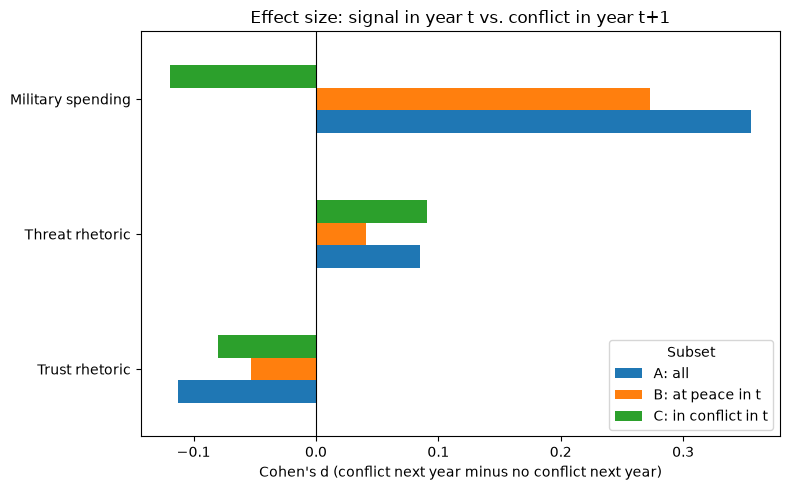

In [26]:
variable_labels = {
    "trust_score": "Trust rhetoric",
    "threat_score": "Threat rhetoric",
    "milex_pct_gdp": "Military spending",
}
effect_table = results.pivot(index="variable", columns="subset", values="cohens_d")
effect_table = effect_table.loc[variables].rename(index=variable_labels)

fig, ax = plt.subplots(figsize=(8, 5))
effect_table.plot.barh(ax=ax)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Cohen's d (conflict next year minus no conflict next year)")
ax.set_ylabel("")
ax.set_title("Effect size: signal in year t vs. conflict in year t+1")
ax.legend(title="Subset")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "effect_sizes.pdf"), bbox_inches="tight")
plt.show()

## 10. Robustness check and trends

### 10.1 Is speech length a confound?

Speeches are longer in the earlier years of our window, especially in the 1990s. If longer speeches scored systematically higher or lower, length rather than content could drive the rhetoric scores. We therefore check the correlation between speech length (in tokens) and both scores.

               speech_length  trust_score  threat_score
speech_length       1.000000     0.010517     -0.017800
trust_score         0.010517     1.000000     -0.091499
threat_score       -0.017800    -0.091499      1.000000


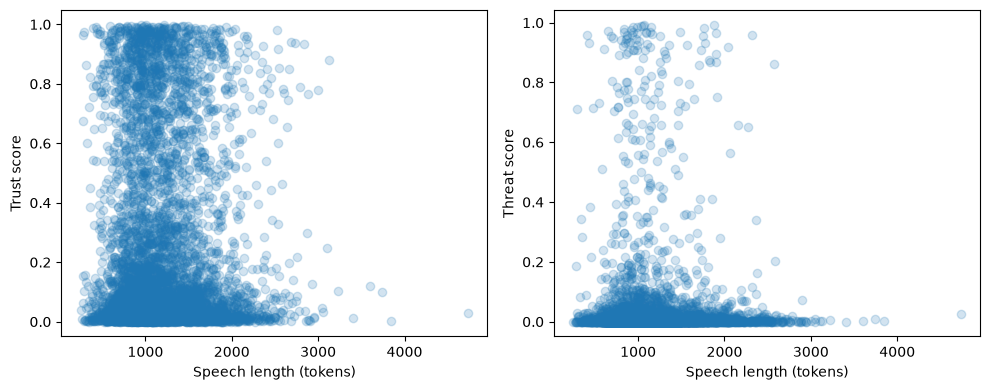

In [27]:
correlation = merged[["speech_length", "trust_score", "threat_score"]].corr()
print(correlation)

# Visual check
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(merged["speech_length"], merged["trust_score"], alpha=0.2)
axes[0].set_xlabel("Speech length (tokens)")
axes[0].set_ylabel("Trust score")

axes[1].scatter(merged["speech_length"], merged["threat_score"], alpha=0.2)
axes[1].set_xlabel("Speech length (tokens)")
axes[1].set_ylabel("Threat score")

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "length_vs_scores.pdf"), bbox_inches="tight")
plt.show()

### 10.2 Rhetoric over time

Average trust/cooperation and military-threat scores per year across the 1990 to 2025 window. Note that 88% of the 2025 speeches start with the chair's introduction ("The Assembly will hear an address by..."), which uses about 45 of the 512 tokens the model reads. 2025 has no outcome, so this only affects this chart, not the group comparison.

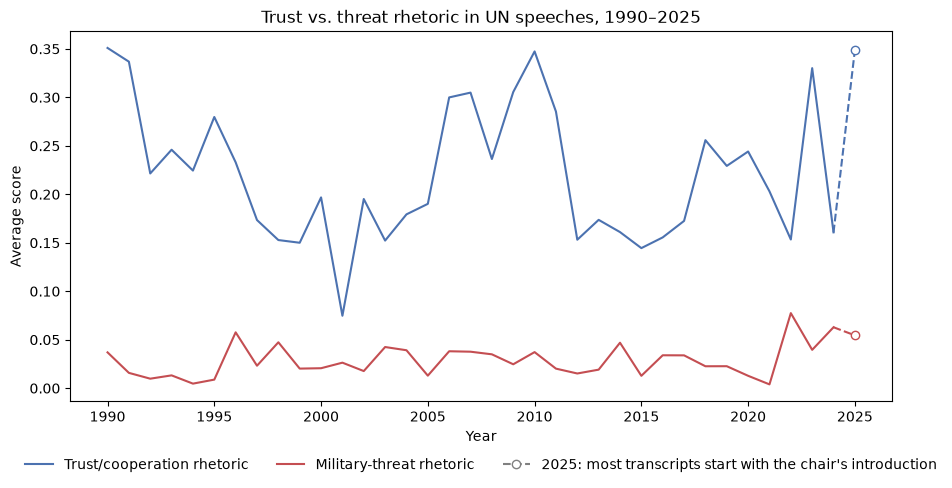

In [28]:
trend = merged.groupby("Year")[["trust_score", "threat_score"]].mean()

trend_until_2024 = trend.loc[:2024]
trend_2024_2025 = trend.loc[2024:2025]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(trend_until_2024.index, trend_until_2024["trust_score"], label="Trust/cooperation rhetoric", color="#4C72B0")
ax.plot(trend_until_2024.index, trend_until_2024["threat_score"], label="Military-threat rhetoric", color="#C44E52")

# 2025: most transcripts start with the chair's introduction, so draw it dashed with a hollow marker
ax.plot(trend_2024_2025.index, trend_2024_2025["trust_score"], color="#4C72B0", linestyle="--",
        marker="o", markevery=[1], markerfacecolor="white")
ax.plot(trend_2024_2025.index, trend_2024_2025["threat_score"], color="#C44E52", linestyle="--",
        marker="o", markevery=[1], markerfacecolor="white")
# Empty plot that only adds the 2025 entry to the legend
ax.plot([], [], color="grey", linestyle="--", marker="o", markerfacecolor="white",
        label="2025: most transcripts start with the chair's introduction")
ax.set_xlabel("Year")
ax.set_ylabel("Average score")
# Legend below the plot, so it does not cover the 1990 values
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
ax.set_title("Trust vs. threat rhetoric in UN speeches, 1990–2025")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "rhetoric_trend.pdf"), bbox_inches="tight")
plt.show()

### 10.3 Military spending over time

Average military spending per year, split by whether the country is in conflict the following year. This shows whether the spending gap is stable over time. 2025 is not shown because it has no outcome.

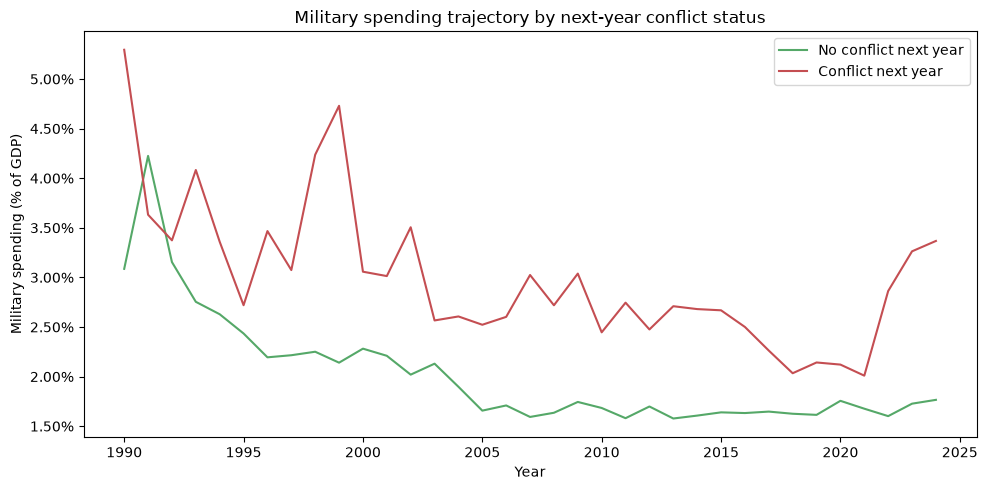

In [29]:
spend_trend = with_outcome.groupby(["Year", "conflict_active_next_year"])["milex_pct_gdp"].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 5))
spend_trend[0.0].plot(ax=ax, label="No conflict next year", color="#55A868")
spend_trend[1.0].plot(ax=ax, label="Conflict next year", color="#C44E52")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_ylabel("Military spending (% of GDP)")
ax.legend()
ax.set_title("Military spending trajectory by next-year conflict status")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_PATH, "spending_trend.pdf"), bbox_inches="tight")
plt.show()

## 11. Summary of findings

- **All speeches (A):** speeches followed by conflict next year have slightly lower trust scores (0.189 vs 0.224; t-test p < 0.001, d = -0.11), slightly higher threat scores (0.037 vs 0.027; p = 0.012, d = 0.08) and higher military spending (2.98% vs 1.98% of GDP; p < 0.0001, d = 0.36). Most of these speeches (903 of 1,062) come from countries already in conflict in year t, so panel A partly reflects that conflicts tend to persist.
- **Countries at peace (B, new conflict onset):** only spending differs (2.45% vs 1.93%, p = 0.002, d = 0.27); the rhetoric differences are small and not significant.
- **Countries in conflict (C):** no difference is significant at the 0.05 level. For spending the t-test gives p = 0.20 and the Mann-Whitney test p = 0.055 (d = -0.12); the Mann-Whitney p is close to the threshold, so we treat this result as uncertain.
- **Caveat:** all rhetoric effects are small, and the scores only describe the opening of each speech (the first 512 of about 2,900 tokens), so they should be read with caution.

## 12. Numbers used in the report

This section prints every number the report uses that is not already printed above, with at least four decimals so that rounding can be checked. It only reads results computed earlier and changes nothing. The token counts in 12.7 use the classifier's tokenizer (a small download on first use); the model itself is not run.

### 12.1 Data preparation

In [30]:
kept_raw_names = excel.loc[speach_df.index, "Country"]
print(f"Distinct raw country names (11,080 speeches): {kept_raw_names.nunique()}")
print(f"After stripping whitespace: {kept_raw_names.astype(str).str.strip().nunique()}")
print(f"After the rename dictionary: {n_names_after_rename}")

unmatched_in_window = []
for file_name in unmatched_files:
    file_year = int(file_name[:-4].split("_")[2])
    if 1990 <= file_year <= 2025:
        unmatched_in_window.append(file_name)
print(f"\nFiles without metadata match: {len(unmatched_files)}, of which in 1990-2025: {len(unmatched_in_window)}")
print(sorted(unmatched_in_window))

n_flagged_speeches = speach_df["historical_entity_unmatched"].sum()
n_flagged_ucdp = conflicts_df["historical_entity_unmatched"].sum()
print(f"\nFlagged speeches: {n_flagged_speeches} of {len(speach_df)} ({n_flagged_speeches / len(speach_df):.4%})")
print(f"Flagged UCDP rows: {n_flagged_ucdp} of {len(conflicts_df)} ({n_flagged_ucdp / len(conflicts_df):.4%})")

ucdp_raw = pd.read_csv(CONFLICTS_PATH)
interstate_share = (ucdp_raw["type_of_conflict"] == 2).mean()
print(f"\nInterstate conflicts (type 2) among the {len(ucdp_raw)} raw UCDP rows: {interstate_share:.4%}")
print(f"UCDP country-years with a conflict: {len(conflicts_agg)}")
print(f"Speeches renamed by the ISO step: {n_renamed}")

Distinct raw country names (11,080 speeches): 757
After stripping whitespace: 550
After the rename dictionary: 514

Files without metadata match: 78, of which in 1990-2025: 18
['AUS_49_1994.txt', 'COM_56_2001.txt', 'CUB_49_1994.txt', 'CZE_49_1994.txt', 'EU_66_2011.txt', 'EU_68_2013.txt', 'EU_69_2014.txt', 'GAB_49_1994.txt', 'KEN_49_1994.txt', 'KWT_49_1994.txt', 'MOZ_49_1994.txt', 'PRK_72_2017.txt', 'PRT_71_2016.txt', 'PRT_72_2017.txt', 'PRT_75_2020.txt', 'SWZ_56_2001.txt', 'TUN_49_1994.txt', 'ZAF_71_2016.txt']

Flagged speeches: 248 of 11080 (2.2383%)
Flagged UCDP rows: 101 of 2990 (3.3779%)

Interstate conflicts (type 2) among the 2816 raw UCDP rows: 5.5043%
UCDP country-years with a conflict: 2024
Speeches renamed by the ISO step: 1089


### 12.2 Final dataset and missing data

In [31]:
print(f"Speeches in scope: {len(merged)}")
print(f"Conflict in the same year: {merged['conflict_active'].mean():.4%}")
print(f"With SIPRI spending: {merged['milex_pct_gdp'].notna().mean():.4%}")

n_missing_spending = merged["milex_pct_gdp"].isna().sum()
print(f"\nMissing spending: {n_missing_spending} of {len(merged)} ({n_missing_spending / len(merged):.4%})")
print(f"Spending available among speeches with an outcome: {with_outcome['milex_pct_gdp'].notna().sum()} of {len(with_outcome)}")
print("Countries with the most missing spending:")
print(merged.loc[merged["milex_pct_gdp"].isna(), "Country"].value_counts().head(15).to_string())

observers = ["Palestine", "Holy See", "European Union"]
is_observer = merged["Country"].isin(observers)
print(f"\nObserver speeches (Palestine, Holy See, European Union): {is_observer.sum()}")
print(merged.loc[is_observer, "Country"].value_counts().to_string())

Speeches in scope: 6680
Conflict in the same year: 16.4222%
With SIPRI spending: 77.9491%

Missing spending: 1473 of 6680 (22.0509%)
Spending available among speeches with an outcome: 5060 of 6490
Countries with the most missing spending:
Country
Antigua and Barbuda                 36
Bahamas                             36
Barbados                            36
Grenada                             36
Saint Kitts and Nevis               36
Liechtenstein                       36
Maldives                            36
Solomon Islands                     36
Suriname                            36
Saint Vincent and the Grenadines    36
Bhutan                              35
Saint Lucia                         35
Comoros                             34
Micronesia                          34
Marshall Islands                    34

Observer speeches (Palestine, Holy See, European Union): 61
Country
Palestine         28
Holy See          22
European Union    11


### 12.3 Per year

In [32]:
per_year = merged.groupby("Year").agg(
    speeches=("Speech", "size"),
    conflict_rate=("conflict_active", "mean"),
    spending_available=("milex_pct_gdp", "count"),
    mean_tokens=("speech_length", "mean"),
)
per_year["sipri_coverage"] = per_year["spending_available"] / per_year["speeches"]
per_year = per_year.drop(columns="spending_available")
print(per_year.to_string(float_format="{:.4f}".format))

print(f"\nSpeeches per year: {per_year['speeches'].min()} to {per_year['speeches'].max()}")
print(f"Conflict rate: {per_year['conflict_rate'].min():.4%} ({per_year['conflict_rate'].idxmin()}) to {per_year['conflict_rate'].max():.4%} ({per_year['conflict_rate'].idxmax()})")
print(f"SIPRI coverage: {per_year['sipri_coverage'].min():.4%} ({per_year['sipri_coverage'].idxmin()}) to {per_year['sipri_coverage'].max():.4%} ({per_year['sipri_coverage'].idxmax()})")

      speeches  conflict_rate  mean_tokens  sipri_coverage
Year                                                      
1990       150         0.2267    1608.6000          0.7600
1991       160         0.2062    1598.2562          0.7438
1992       166         0.2048    1566.1627          0.7470
1993       175         0.1714    1618.9543          0.8000
1994       170         0.2000    1560.0529          0.8059
1995       172         0.1744    1501.7907          0.7849
1996       181         0.1602    1408.6188          0.7735
1997       176         0.1705    1412.6250          0.7898
1998       181         0.1713    1368.1271          0.7569
1999       181         0.1602    1407.4254          0.7680
2000       178         0.1573    1260.0225          0.7809
2001       186         0.1613    1050.6613          0.7634
2002       187         0.1337     981.9144          0.7754
2003       188         0.1489    1025.3830          0.7979
2004       191         0.1309    1027.8063          0.80

### 12.4 Outcome

In [33]:
n_with_outcome = len(with_outcome)
n_followed = (with_outcome["conflict_active_next_year"] == 1).sum()
n_at_peace = len(at_peace)
n_in_conflict = len(in_conflict)
n_onset = (at_peace["conflict_active_next_year"] == 1).sum()
n_continued = (in_conflict["conflict_active_next_year"] == 1).sum()

print(f"Speeches with an outcome: {n_with_outcome}")
print(f"Followed by conflict: {n_followed} ({n_followed / n_with_outcome:.4%})")
print(f"At peace in year t: {n_at_peace}; in conflict in year t: {n_in_conflict}")
print(f"New conflicts among countries at peace: {n_onset} ({n_onset / n_at_peace:.4%})")
print(f"Continued conflicts among countries in conflict: {n_continued} ({n_continued / n_in_conflict:.4%})")
print(f"Share of 'followed by conflict' that were already in conflict: {n_continued / n_followed:.4%}")

Speeches with an outcome: 6490
Followed by conflict: 1062 (16.3636%)
At peace in year t: 5428; in conflict in year t: 1062
New conflicts among countries at peace: 159 (2.9293%)
Continued conflicts among countries in conflict: 903 (85.0282%)
Share of 'followed by conflict' that were already in conflict: 85.0282%


### 12.5 Group comparison with exact values

The 95% confidence interval for Cohen's d uses the normal approximation with SE = sqrt((n0 + n1) / (n0 n1) + d^2 / (2 (n0 + n1))). The minimum detectable d is the smallest effect a two-sided test at the 5% level finds with 80% power, given the group sizes.

In [34]:
def add_confidence_interval(table):
    """Add an approximate 95% confidence interval for Cohen's d."""
    table = table.copy()
    n0 = table["n0"]
    n1 = table["n1"]
    d = table["cohens_d"]
    se = np.sqrt((n0 + n1) / (n0 * n1) + d ** 2 / (2 * (n0 + n1)))
    table["d_ci_low"] = d - 1.96 * se
    table["d_ci_high"] = d + 1.96 * se
    return table


def minimum_detectable_d(n0, n1):
    """Smallest d found with 80% power by a two-sided test at the 5% level."""
    z_sum = stats.norm.ppf(0.975) + stats.norm.ppf(0.80)
    return z_sum * np.sqrt(1 / n0 + 1 / n1)


exact_results = add_confidence_interval(results)
exact_results["min_detectable_d"] = minimum_detectable_d(exact_results["n0"], exact_results["n1"])
print(exact_results.to_string(float_format="{:.6f}".format))

print("\nMean and SD by conflict next year:")
print(with_outcome.groupby("conflict_active_next_year")[["trust_score", "threat_score"]].agg(["mean", "std", "count"]).to_string(float_format="{:.6f}".format))

                subset       variable    n0    n1    mean0    mean1  t_test_p  mann_whitney_p  cohens_d  d_ci_low  d_ci_high  min_detectable_d
0               A: all    trust_score  5428  1062 0.223646 0.189417  0.000807        0.000063 -0.112467 -0.178261  -0.046673          0.094003
1               A: all   threat_score  5428  1062 0.026961 0.037019  0.011539        0.000017  0.084779  0.018998   0.150560          0.094003
2               A: all  milex_pct_gdp  4104   956 0.019834 0.029830  0.000000        0.000000  0.355405  0.284677   0.426132          0.100611
3     B: at peace in t    trust_score  5269   159 0.224074 0.207856  0.511550        0.321918 -0.052841 -0.210610   0.104928          0.225508
4     B: at peace in t   threat_score  5269   159 0.027000 0.031688  0.612551        0.784158  0.040767 -0.117001   0.198535          0.225508
5     B: at peace in t  milex_pct_gdp  3968   140 0.019252 0.024467  0.001501        0.001736  0.273171  0.104520   0.441822          0.240918

### 12.6 Year-adjusted rhetoric scores

We subtract each year's mean from the two scores and rerun the comparison for panels A and B. If the differences stay, they do not simply come from years with higher scores and more conflict.

In [35]:
adjusted = merged.copy()
for column in ["trust_score", "threat_score"]:
    year_mean = adjusted.groupby("Year")[column].transform("mean")
    adjusted[column + "_year_adjusted"] = adjusted[column] - year_mean

adjusted_columns = ["trust_score_year_adjusted", "threat_score_year_adjusted"]
adjusted_outcome = adjusted[adjusted["conflict_active_next_year"].notna()]
adjusted_at_peace = adjusted_outcome[adjusted_outcome["conflict_active"] == 0]

adjusted_results = pd.concat(
    [
        compare(adjusted_outcome, "A: all", adjusted_columns),
        compare(adjusted_at_peace, "B: at peace in t", adjusted_columns),
    ],
    ignore_index=True,
)
print(add_confidence_interval(adjusted_results).to_string(float_format="{:.6f}".format))

             subset                    variable    n0    n1     mean0     mean1  t_test_p  mann_whitney_p  cohens_d  d_ci_low  d_ci_high
0            A: all   trust_score_year_adjusted  5428  1062  0.005795 -0.029620  0.000378        0.000187 -0.119350 -0.185147  -0.053553
1            A: all  threat_score_year_adjusted  5428  1062 -0.001692  0.008646  0.008729        0.001744  0.088020  0.022238   0.153803
2  B: at peace in t   trust_score_year_adjusted  5269   159  0.006269 -0.016114  0.353143        0.692181 -0.074745 -0.232517   0.083027
3  B: at peace in t  threat_score_year_adjusted  5269   159 -0.001662  0.004672  0.489172        0.287852  0.055675 -0.102095   0.213444


### 12.7 Speech length, keywords and classifier tokens

In [36]:
print(f"speech_length vs trust_score:  r = {merged['speech_length'].corr(merged['trust_score']):.6f}")
print(f"speech_length vs threat_score: r = {merged['speech_length'].corr(merged['threat_score']):.6f}")
print(f"trust_score vs threat_score:   r = {merged['trust_score'].corr(merged['threat_score']):.6f}")
print(f"\nMean speech length after cleaning: {merged['speech_length'].mean():.4f} tokens (median {merged['speech_length'].median():.0f})")
print("Mean speech length by decade of the window:")
decade = (merged["Year"] // 10) * 10
print(merged.groupby(decade)["speech_length"].mean().round(4).to_string())
print("\nTrust-lexicon rate (% of cleaned words) by conflict next year:")
print((lexicon_by_group * 100).to_string(float_format="{:.6f}".format))

speech_length vs trust_score:  r = 0.010517
speech_length vs threat_score: r = -0.017800
trust_score vs threat_score:   r = -0.091499

Mean speech length after cleaning: 1176.6507 tokens (median 1102)
Mean speech length by decade of the window:
Year
1990    1501.0426
2000    1027.2241
2010    1085.6599
2020    1091.4866

Trust-lexicon rate (% of cleaned words) by conflict next year:
conflict_active_next_year
0.0   0.960646
1.0   0.983249


In [37]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("MoritzLaurer/ModernBERT-large-zeroshot-v2.0")

classifier_tokens = []
for speech_text in merged["Speech"]:
    classifier_tokens.append(len(tokenizer(speech_text)["input_ids"]))
classifier_tokens = pd.Series(classifier_tokens)

print(f"Classifier limit: {tokenizer.model_max_length} tokens")
print(f"Classifier tokens per speech: mean {classifier_tokens.mean():.4f}, median {classifier_tokens.median():.0f}, "
      f"min {classifier_tokens.min()}, max {classifier_tokens.max()}")
print(f"Speeches longer than the limit: {(classifier_tokens > tokenizer.model_max_length).sum()} of {len(classifier_tokens)}")

/Users/jakubkucz/Library/CloudStorage/OneDrive-UvA/UvA/FDS/A1/code/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (3189 > 512). Running this sequence through the model will result in indexing errors


Classifier limit: 512 tokens
Classifier tokens per speech: mean 2939.4487, median 2765, min 569, max 14881
Speeches longer than the limit: 6680 of 6680


### 12.8 Chair introductions in 2025

Most 2025 transcripts begin with the chair's introduction ("The Assembly will hear an address by..."). We count how often the first 200 characters contain one of three chair phrases, and how many classifier tokens the introduction takes, up to the chair's last sentence inviting the speaker.

In [38]:
chair_phrases = ["The Assembly", "I now give the floor", "I call"]
chair_end_pattern = r"(address the (General )?Assembly\.|escorted from the rostrum\.|escorted into the General Assembly Hall\.)"


def starts_with_chair(speech_text):
    opening = speech_text[:200]
    for phrase in chair_phrases:
        if phrase in opening:
            return True
    return False


def chair_intro_tokens(speech_text):
    """Classifier tokens up to the end of the chair's introduction, or None if none is found."""
    matches = list(re.finditer(chair_end_pattern, speech_text[:3000]))
    if not matches:
        return None
    intro = speech_text[:matches[-1].end()]
    return len(tokenizer(intro)["input_ids"])


merged_2025 = merged[merged["Year"] == 2025]
chair_share = merged_2025["Speech"].apply(starts_with_chair).mean()
intro_tokens = merged_2025["Speech"].apply(chair_intro_tokens).dropna()
print(f"2025 speeches starting with a chair phrase: {chair_share:.4%} of {len(merged_2025)}")
print(f"Introductions found: {len(intro_tokens)}; tokens median {intro_tokens.median():.1f}, mean {intro_tokens.mean():.4f}, max {intro_tokens.max():.0f}")

share_other_years = merged[merged["Year"] < 2025]["Speech"].apply(starts_with_chair).mean()
print(f"Same share in 1990-2024: {share_other_years:.4%}")

2025 speeches starting with a chair phrase: 87.8947% of 190
Introductions found: 128; tokens median 45.0, mean 46.2188, max 72
Same share in 1990-2024: 0.1079%


### 12.9 Values quoted from the figures

In [39]:
print("Average scores per year (selected years):")
print(trend.loc[[1990, 2001, 2021, 2022, 2025]].to_string(float_format="{:.6f}".format))
print("\nAverage spending (fraction of GDP) by conflict next year:")
print(spend_trend.loc[[1990, 2024]].to_string(float_format="{:.6f}".format))
print("\nCohen's d per panel (effect-size figure):")
print(effect_table.to_string(float_format="{:.6f}".format))

Average scores per year (selected years):
      trust_score  threat_score
Year                           
1990     0.350969      0.036965
2001     0.074709      0.026330
2021     0.203046      0.003939
2022     0.153379      0.077443
2025     0.348931      0.054502

Average spending (fraction of GDP) by conflict next year:
conflict_active_next_year      0.0      1.0
Year                                       
1990                      0.030863 0.052949
2024                      0.017656 0.033675

Cohen's d per panel (effect-size figure):
subset               A: all  B: at peace in t  C: in conflict in t
variable                                                          
Trust rhetoric    -0.112467         -0.052841            -0.080035
Threat rhetoric    0.084779          0.040767             0.090511
Military spending  0.355405          0.273171            -0.119424
